文字の読み取りというより、領域をざっくり分けて、サイズ感も出せば、タイトルか本文かの区別をしてみようって感じ

In [2]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 画像をアップロード
uploaded = files.upload()

# ファイル名
filename = list(uploaded.keys())[0]
print("ファイル名:", filename)

# OpenCVで直接読み込む
img = cv2.imdecode(
    __import__('numpy').frombuffer(uploaded[filename], dtype='uint8'),
    cv2.IMREAD_COLOR
)

# 読み込み確認
if img is None:
    print("❌ 画像を読み込めませんでした")
else:
    print("✅ 画像を読み込みました")
    print("画像サイズ:", img.shape)

    # OpenCV → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

ModuleNotFoundError: No module named 'google'

白黒画像の作成。背景を黒、文字、線を白に変換

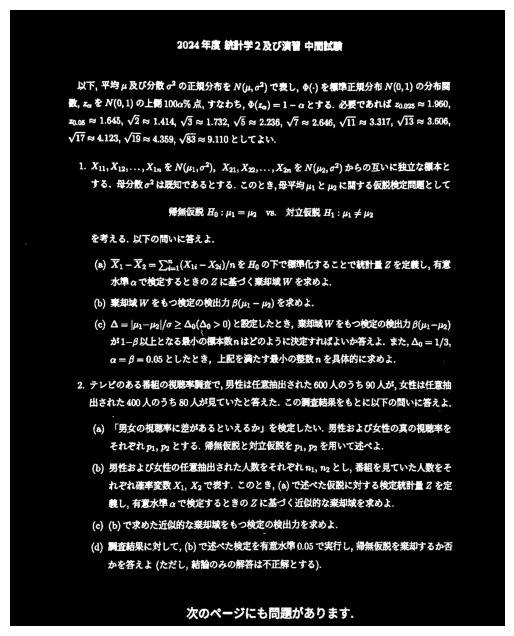

In [13]:
# グレースケール化
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 白黒にする
_, binary = cv2.threshold(
    gray,
    200,
    255,
    cv2.THRESH_BINARY_INV
)

# 表示
plt.figure(figsize=(12, 8))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

文字にまとまりを作る。一文字ずつバラバラになりやすいので、近くにある文字同士をくっつける。かたまりを判別

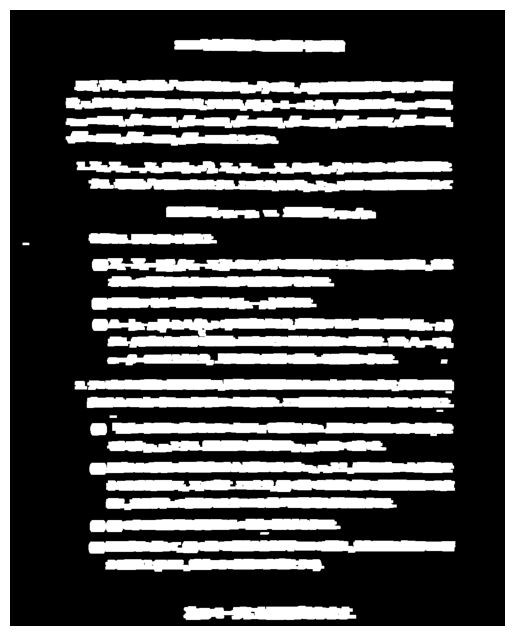

In [14]:
# 文字同士を近づけて、まとまりとして扱う
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 5)
)

dilated = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

# 表示
plt.figure(figsize=(12, 8))
plt.imshow(dilated, cmap="gray")
plt.axis("off")
plt.show()

contoursによって、まとまり（領域）の数を見つける

In [15]:
contours, _ = cv2.findContours(
    dilated,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("検出した領域数:", len(contours))

検出した領域数: 39


その領域を四角で囲む
小さすぎる領域は無視する。ここのサイズ感は改良の余地あり

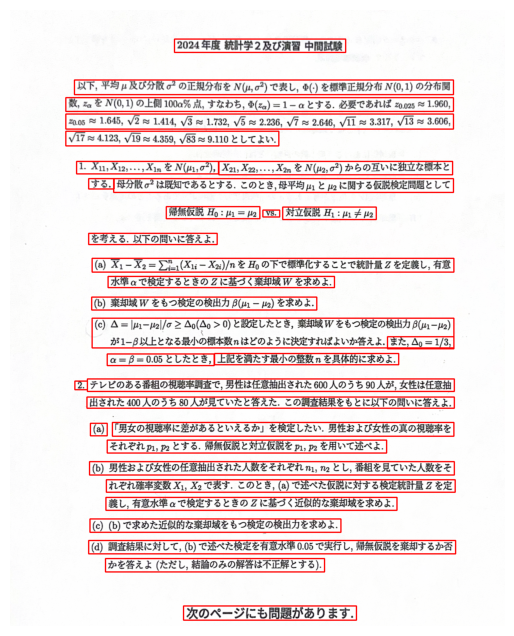

In [16]:
result = img.copy()

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)

    # 小さすぎる領域は無視
    if w > 20 and h > 10:

        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

# RGBに変換して表示
result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(result_rgb)
plt.axis("off")
plt.show()